# MODELO DE REDES NEURONALES - PRODUCTO IA 2

### 🧠 Objetivo del código

El presente código tiene como finalidad **realizar la predicción de tres variables objetivo** —*Rendimiento académico*, *Riesgo de deserción* y *Bienestar estudiantil*— mediante el uso de **redes neuronales artificiales**.  
Cada modelo utiliza únicamente las **variables influyentes específicas** que ejercen mayor impacto sobre su resultado, con el fin de **reducir el ruido de 
los datos, mejorar la interpretabilidad del modelo y optimizar la precisión de los pronósticos**.

---
### 👥 Integrantes

- **Chavarri Centeno, Jorge Andrés**  
- **Lanche Cerrón, Hilter Piero** 
- **Rivera Matías, Joel**  
- **Guevara Huasco, Abel**
---

Variables que vamos a utilizar para cada una de las variables objetivo:

| **Variable objetivo**     | **Variables influyentes (inputs)**                                  |
|----------------------------|---------------------------------------------------------------------|
| **Rendimiento académico**  | `PPS_actual`, `horas_estudio_semana`, `indice_procrastinacion`     |
| **Riesgo de deserción**    | `horas_trabajo_semana`, `estres`, `apoyo_social`                   |
| **Bienestar estudiantil**  | `estres`, `apoyo_social`, `horas_extracurriculares`                |

---

In [6]:
#!pip install tensorflow

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached keras-3.12.0-py3-none-any.whl.metadata (5.9 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached keras-3.12.0-py3-none-any.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]2 [tensorflow]


In [1]:
#Importamos las librerias necesarias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

2025-11-06 20:53:59.753260: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-06 20:53:59.773937: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 20:54:00.483103: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 20:54:03.609680: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [3]:
#Importamos los datos
ruta = 'sintetico_netica.csv'
df = pd.read_csv(ruta)

# Vista rápida
df.head()

,asistencia_laboratorio_pct,asistencia_teorico_pct,asistencia_total_pct,entregas_tarea_puntual,horas_de_estudio_semana,puntualidad_pago,ingresos_mensual,deuda_academica,tipo_financiamiento,costo_servicio_mensual,...,horas_pantalla_no_academica,horas_sueno,habitos_vida,horas_trabajo_semana,apoyo_social,estres,bienestar_estudiantil,pps_actual_20,rendimiento,riesgo_de_desercion
0,Media,Baja,Baja,Ejemplar,Insuficiente,Puntual,Muy_Bajo,Con_deuda,Financiamiento_Familiar,Bajo,...,Bajo,Deficiente,Regular,Tiempo_Completo,Excelente,Moderado,Excelente,En_Proceso,Inicio,Medio
1,Alta,Alta,Excelente,Critico,Adecuado,Impuntual,Medio,Con_deuda,Beca_Total,Muy_Bajo,...,Alto,Adecuado,Bueno,Parcial_Baja,Insuficiente,Bajo,Excelente,Inicio,Previsto,Bajo
2,Media,Alta,Alta,Moderado,Insuficiente,Impuntual,Alto,Sin_deuda,Beca_Parcial,Medio,...,Moderado,Regular,Deficiente,Ninguna,Moderado,Moderado,Critico,Previsto,Inicio,Bajo
3,Alta,Excelente,Excelente,Consistente,Intensivo,Puntual,Alto,Con_deuda,Financiamiento_Familiar,Bajo,...,Bajo,Deficiente,Bueno,Parcial_Baja,Bueno,Moderado,Excelente,Previsto,Destacado,Bajo
4,Excelente,Media,Excelente,Critico,Intensivo,Puntual,Muy_Bajo,Sin_deuda,Financiamiento_Familiar,Medio,...,Alto,Adecuado,Regular,Tiempo_Completo,Excelente,Muy_Alto,Regular,Previsto,Destacado,Alto


In [4]:
#Chequeo de nulos
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   asistencia_laboratorio_pct   10000 non-null  object
 1   asistencia_teorico_pct       10000 non-null  object
 2   asistencia_total_pct         10000 non-null  object
 3   entregas_tarea_puntual       10000 non-null  object
 4   horas_de_estudio_semana      10000 non-null  object
 5   puntualidad_pago             10000 non-null  object
 6   ingresos_mensual             10000 non-null  object
 7   deuda_academica              10000 non-null  object
 8   tipo_financiamiento          10000 non-null  object
 9   costo_servicio_mensual       10000 non-null  object
 10  indice_financiero            10000 non-null  object
 11  indice_procrastinacion       10000 non-null  object
 12  horas_deporte                10000 non-null  object
 13  horas_cultura                100

asistencia_laboratorio_pct    0
horas_extracurriculares       0
rendimiento                   0
pps_actual_20                 0
bienestar_estudiantil         0
estres                        0
apoyo_social                  0
horas_trabajo_semana          0
habitos_vida                  0
horas_sueno                   0
dtype: int64

### ✅ Modelo para rendimiento

In [5]:
# Variables influyentes para la variable objetivo 'Rendimiento'
X_cols = ['pps_actual_20', 'horas_de_estudio_semana', 'indice_procrastinacion']
y_col  = 'rendimiento'   

# Crear un nuevo DataFrame solo con esas columnas
df_rend = df[X_cols + [y_col]].copy()

# Revisar los valores únicos para validar codificación
for c in df_rend.columns:
    print(c, '->', df_rend[c].unique())


pps_actual_20 -> ['En_Proceso' 'Inicio' 'Previsto' 'Destacado']
horas_de_estudio_semana -> ['Insuficiente' 'Adecuado' 'Intensivo' 'Limitado']
indice_procrastinacion -> ['Frecuente' 'Constante' 'Minimo' 'Ocasional']
rendimiento -> ['Inicio' 'Previsto' 'Destacado' 'En_Proceso']


In [6]:
# Separamos variables de entrada y salida
X = df_rend[X_cols].copy()
y = df_rend[y_col].copy()

In [7]:
# Distribución global
df_rend[y_col].value_counts(normalize=True)

rendimiento
Destacado     0.3574
En_Proceso    0.2249
Inicio        0.2177
Previsto      0.2000
Name: proportion, dtype: float64

In [8]:
# --- Codificación del target (salida) con orden manual ---
orden_rendimiento = ['Destacado', 'Previsto', 'En_Proceso', 'Inicio']

# Mapea según el orden deseado
y_enc = df_rend[y_col].map({cat: i for i, cat in enumerate(orden_rendimiento)})

print("Valores codificados de rendimiento:", y_enc.unique())
for cat, val in {cat: i for i, cat in enumerate(orden_rendimiento)}.items():
    print(f"{cat} → {val}")

# Identificar columnas categóricas y numéricas
cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if X[c].dtype != 'object']

# --- Preprocesador para las variables de entrada ---
preprocessor_rend = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='drop'
)

# --- Dividir el dataset en train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# --- Aplicar el preprocesador ---
X_train_proc = preprocessor_rend.fit_transform(X_train)
X_test_proc  = preprocessor_rend.transform(X_test)


Valores codificados de rendimiento: [3 1 0 2]
Destacado → 0
Previsto → 1
En_Proceso → 2
Inicio → 3


In [9]:
# Definir dimensiones
input_dim = X_train_proc.shape[1]
n_classes = len(np.unique(y_enc))

# Crear la red neuronal
modelo_rend = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compilar
modelo_rend.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Entrenar
hist_rend = modelo_rend.fit(
    X_train_proc, y_train,
    validation_data=(X_test_proc, y_test),
    epochs=60, batch_size=16, verbose=1
)


2025-11-06 20:54:37.137911: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4506 - loss: 1.1883 - val_accuracy: 0.5135 - val_loss: 1.0885
Epoch 2/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5209 - loss: 1.0699 - val_accuracy: 0.5250 - val_loss: 1.0281
Epoch 3/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5274 - loss: 1.0407 - val_accuracy: 0.5305 - val_loss: 1.0190
Epoch 4/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5321 - loss: 1.0343 - val_accuracy: 0.5175 - val_loss: 1.0189
Epoch 5/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5320 - loss: 1.0304 - val_accuracy: 0.5260 - val_loss: 1.0139
Epoch 6/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5321 - loss: 1.0276 - val_accuracy: 0.5340 - val_loss: 1.0131
Epoch 7/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5337 - loss: 1.0254 - val_accuracy: 0.5295 - val_loss: 1.0131
Epoch 8/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5316 - loss: 1.0237 - val_accuracy: 0.

In [10]:
from sklearn.metrics import classification_report, balanced_accuracy_score

y_pred = np.argmax(modelo_rend.predict(X_test_proc), axis=1)

print("Accuracy:", (y_pred == y_test).mean())
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Destacado','En_Proceso','Previsto','Inicio']))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.5235
Balanced Accuracy: 0.47313215041663315
              precision    recall  f1-score   support

   Destacado       0.69      0.80      0.74       715
  En_Proceso       0.38      0.17      0.24       400
    Previsto       0.31      0.42      0.36       450
      Inicio       0.57      0.50      0.53       435

    accuracy                           0.52      2000
   macro avg       0.49      0.47      0.47      2000
weighted avg       0.52      0.52      0.51      2000



In [11]:
# Evaluacion del modelo
loss, acc = modelo_rend.evaluate(X_test_proc, y_test, verbose=0)
print(f'Exactitud (Accuracy) en test: {acc:.3f}')

Exactitud (Accuracy) en test: 0.524


In [12]:
def clasificar_nota_pps(nota):
    """
    Transforma una nota numérica (0–20) en su categoría de PPS_actual.
    """
    if nota < 11:
        return 'Inicio'
    elif nota < 14:
        return 'En_Proceso'
    elif nota < 17:
        return 'Previsto'
    else:
        return 'Destacado'

In [13]:
# Escenario crítico
nuevo_estudiante = pd.DataFrame({
    'pps_actual_20': [clasificar_nota_pps(11)],
    'horas_de_estudio_semana': ['Limitado'],
    'indice_procrastinacion': ['Minimo']
})

# Transformar
X_new_proc = preprocessor_rend.transform(nuevo_estudiante)

# Predecir
proba = modelo_rend.predict(X_new_proc, verbose=0)[0]
pred_label = orden_rendimiento[np.argmax(proba)]

# Mostrar resultados
print("Umbral de nota: "  ,clasificar_nota_pps(11))
print("Predicción:", pred_label)
print("Probabilidades:", dict(zip(orden_rendimiento, np.round(proba, 3))))


Umbral de nota:  En_Proceso
Predicción: En_Proceso
Probabilidades: {'Destacado': 0.295, 'Previsto': 0.317, 'En_Proceso': 0.323, 'Inicio': 0.065}


### ✅ Modelo para riesgo de desercion

In [14]:
# Variables influyentes para la variable objetivo 'Riesgo de deserción'
X_cols_des = ['horas_trabajo_semana', 'estres', 'apoyo_social']
y_col_des  = 'riesgo_de_desercion'   # asegúrate de que así se llama en tu CSV

# Crear un nuevo DataFrame solo con esas columnas
df_des = df[X_cols_des + [y_col_des]].copy()

# Revisar los valores únicos para validar codificación
for c in df_des.columns:
    print(c, '->', df_des[c].unique())


horas_trabajo_semana -> ['Tiempo_Completo' 'Parcial_Baja' 'Ninguna' 'Parcial_Alta']
estres -> ['Moderado' 'Bajo' 'Muy_Alto' 'Alto']
apoyo_social -> ['Excelente' 'Insuficiente' 'Moderado' 'Bueno']
riesgo_de_desercion -> ['Medio' 'Bajo' 'Alto']


In [15]:
# Separamos variables de entrada y salida
X = df_des[X_cols_des].copy()
y = df_des[y_col_des].copy()

In [16]:
# Distribución global (porcentaje total)
df_des[y_col_des].value_counts(normalize=True)

riesgo_de_desercion
Bajo     0.5623
Medio    0.2554
Alto     0.1823
Name: proportion, dtype: float64

In [17]:
# --- Codificación del target (salida) con orden manual ---
orden_desercion = ['Bajo', 'Medio', 'Alto']   # orden lógico

# Mapea según el orden deseado
y_des_enc = df_des[y_col_des].map({cat: i for i, cat in enumerate(orden_desercion)})

print("Valores codificados de riesgo de deserción:", y_des_enc.unique())
for cat, val in {cat: i for i, cat in enumerate(orden_desercion)}.items():
    print(f"{cat} → {val}")

# Identificar columnas categóricas y numéricas
cat_cols_des = [c for c in X.columns if X[c].dtype == 'object']
num_cols_des = [c for c in X.columns if X[c].dtype != 'object']

# --- Preprocesador para las variables de entrada ---
preprocessor_des = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_des),
        ('num', StandardScaler(), num_cols_des)
    ],
    remainder='drop'
)

# --- Dividir el dataset en train/test ---
X_train_des, X_test_des, y_train_des, y_test_des = train_test_split(
    X, y_des_enc, test_size=0.2, random_state=42, stratify=y_des_enc
)

# --- Aplicar el preprocesador ---
X_train_des_proc = preprocessor_des.fit_transform(X_train_des)
X_test_des_proc  = preprocessor_des.transform(X_test_des)


Valores codificados de riesgo de deserción: [1 0 2]
Bajo → 0
Medio → 1
Alto → 2


In [18]:
# ===============================
# 🧠 RNA – Riesgo de Deserción
# ===============================

# Definir dimensiones
input_dim_des = X_train_des_proc.shape[1]
n_classes_des = len(np.unique(y_des_enc))

# Crear la red neuronal
modelo_des = Sequential([
    Input(shape=(input_dim_des,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(n_classes_des, activation='softmax')
])

# Compilar
modelo_des.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar
hist_des = modelo_des.fit(
    X_train_des_proc, y_train_des,
    validation_data=(X_test_des_proc, y_test_des),
    epochs=60, batch_size=16, verbose=1
)


Epoch 1/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5921 - loss: 0.8830 - val_accuracy: 0.6400 - val_loss: 0.8132
Epoch 2/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6352 - loss: 0.7984 - val_accuracy: 0.6400 - val_loss: 0.7978
Epoch 3/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6366 - loss: 0.7926 - val_accuracy: 0.6495 - val_loss: 0.7951
Epoch 4/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6382 - loss: 0.7903 - val_accuracy: 0.6490 - val_loss: 0.7934
Epoch 5/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6380 - loss: 0.7879 - val_accuracy: 0.6490 - val_loss: 0.7943
Epoch 6/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6389 - loss: 0.7880 - val_accuracy: 0.6425 - val_loss: 0.7921
Epoch 7/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6399 - loss: 0.7867 - val_accuracy: 0.6490 - val_loss: 0.7920
Epoch 8/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6389 - loss: 0.7864 - val_accuracy: 0.

In [19]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predicciones
y_pred_des = np.argmax(modelo_des.predict(X_test_des_proc), axis=1)

# Métricas principales
print("Accuracy:", (y_pred_des == y_test_des).mean())
print("Balanced Accuracy:", balanced_accuracy_score(y_test_des, y_pred_des))
print(classification_report(y_test_des, y_pred_des, target_names=['Bajo', 'Medio', 'Alto']))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.652
Balanced Accuracy: 0.5343597439950972
              precision    recall  f1-score   support

        Bajo       0.71      0.91      0.79      1124
       Medio       0.42      0.20      0.27       511
        Alto       0.58      0.49      0.53       365

    accuracy                           0.65      2000
   macro avg       0.57      0.53      0.53      2000
weighted avg       0.61      0.65      0.61      2000



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Matriz de confusión:
 [[1021   71   32]
 [ 311  103   97]
 [ 116   69  180]]


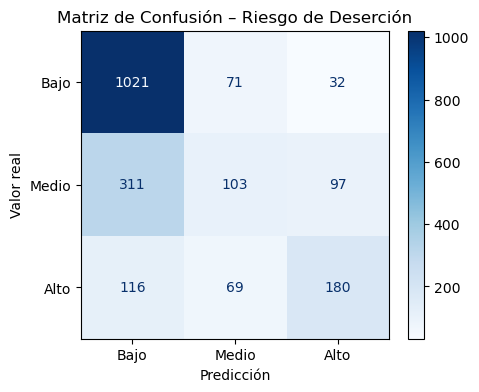

In [69]:
# ===============================
# 📊 Matriz de Confusión – Riesgo de Deserción
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Generar predicciones
y_pred_des = np.argmax(modelo_des.predict(X_test_des_proc), axis=1)

# Calcular la matriz
matriz_des = confusion_matrix(y_test_des, y_pred_des)

# Mostrar en consola
print("Matriz de confusión:\n", matriz_des)

# Visualizar con etiquetas legibles
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz_des, display_labels=orden_desercion).plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión – Riesgo de Deserción")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [20]:
loss_des, acc_des = modelo_des.evaluate(X_test_des_proc, y_test_des, verbose=0)
print(f'Exactitud (Accuracy) en test: {acc_des:.3f}')


Exactitud (Accuracy) en test: 0.652


In [21]:
nuevo_estudiante_des = pd.DataFrame({
    'horas_trabajo_semana': ['Tiempo Completo'],  # ejemplo de carga laboral alta
    'estres': ['Muy Alto'],                       # nivel de estrés extremo
    'apoyo_social': ['Insuficiente']              # poco apoyo social
})

# Transformar el nuevo caso con el preprocesador
X_new_des_proc = preprocessor_des.transform(nuevo_estudiante_des)

# Obtener probabilidades
proba_des = modelo_des.predict(X_new_des_proc, verbose=0)[0]

# Determinar clase predicha
pred_label_des = orden_desercion[np.argmax(proba_des)]

print("Predicción:", pred_label_des)
print("Probabilidades:", dict(zip(orden_desercion, np.round(proba_des, 3))))


Predicción: Medio
Probabilidades: {'Bajo': 0.266, 'Medio': 0.38, 'Alto': 0.355}


### ✅ Modelo para bienestar estudiantil

In [54]:
# Variables influyentes para la variable objetivo 'Bienestar Estudiantil'
X_cols_bien = ['estres', 'apoyo_social']
y_col_bien  = 'bienestar_estudiantil'   # asegúrate de usar el nombre exacto de la columna en tu CSV

# Crear un nuevo DataFrame solo con esas columnas
df_bien = df[X_cols_bien + [y_col_bien]].copy()

# Revisar los valores únicos para validar categorías
for c in df_bien.columns:
    print(c, '->', df_bien[c].unique())


estres -> ['Moderado' 'Bajo' 'Muy_Alto' 'Alto']
apoyo_social -> ['Excelente' 'Insuficiente' 'Moderado' 'Bueno']
bienestar_estudiantil -> ['Excelente' 'Critico' 'Regular']


In [55]:
# Separamos variables de entrada y salida
X = df_bien[X_cols_bien].copy()
y = df_bien[y_col_bien].copy()

In [56]:
# Distribución global (porcentaje total)
df_bien[y_col_bien].value_counts(normalize=True)

bienestar_estudiantil
Excelente    0.5002
Regular      0.2913
Critico      0.2085
Name: proportion, dtype: float64

In [57]:
# --- Codificación del target (salida) con orden manual ---
# Orden lógico: Crítico < Regular < Excelente
orden_bienestar = ['Critico', 'Regular', 'Excelente']   

# Mapea según el orden deseado
y_bien_enc = df_bien[y_col_bien].map({cat: i for i, cat in enumerate(orden_bienestar)})

print("Valores codificados de bienestar estudiantil:", y_bien_enc.unique())
for cat, val in {cat: i for i, cat in enumerate(orden_bienestar)}.items():
    print(f"{cat} → {val}")

# Identificar columnas categóricas y numéricas
cat_cols_bien = [c for c in X.columns if X[c].dtype == 'object']
num_cols_bien = [c for c in X.columns if X[c].dtype != 'object']

# --- Preprocesador para las variables de entrada ---
preprocessor_bien = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_bien),
        ('num', StandardScaler(), num_cols_bien)
    ],
    remainder='drop'
)

# --- Dividir el dataset en train/test ---
X_train_bien, X_test_bien, y_train_bien, y_test_bien = train_test_split(
    X, y_bien_enc, test_size=0.2, random_state=42, stratify=y_bien_enc
)

# --- Aplicar el preprocesador ---
X_train_bien_proc = preprocessor_bien.fit_transform(X_train_bien)
X_test_bien_proc  = preprocessor_bien.transform(X_test_bien)


Valores codificados de bienestar estudiantil: [2 0 1]
Critico → 0
Regular → 1
Excelente → 2


In [58]:
# Definir dimensiones
input_dim_bien = X_train_bien_proc.shape[1]
n_classes_bien = len(np.unique(y_bien_enc))

# Crear la red neuronal
modelo_bien = Sequential([
    Input(shape=(input_dim_bien,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(n_classes_bien, activation='softmax')
])

# Compilar el modelo
modelo_bien.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
hist_bien = modelo_bien.fit(
    X_train_bien_proc, y_train_bien,
    validation_data=(X_test_bien_proc, y_test_bien),
    epochs=60, batch_size=16, verbose=1
)


Epoch 1/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5264 - loss: 0.9774 - val_accuracy: 0.5755 - val_loss: 0.9007
Epoch 2/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5769 - loss: 0.8983 - val_accuracy: 0.5755 - val_loss: 0.8898
Epoch 3/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5792 - loss: 0.8949 - val_accuracy: 0.5850 - val_loss: 0.8894
Epoch 4/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5773 - loss: 0.8939 - val_accuracy: 0.5750 - val_loss: 0.8913
Epoch 5/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5803 - loss: 0.8939 - val_accuracy: 0.5850 - val_loss: 0.8877
Epoch 6/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5782 - loss: 0.8941 - val_accuracy: 0.5765 - val_loss: 0.8874
Epoch 7/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5779 - loss: 0.8936 - val_accuracy: 0.5850 - val_loss: 0.8894
Epoch 8/60
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5817 - loss: 0.8935 - val_accuracy: 0.

In [59]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predicciones
y_pred_bien = np.argmax(modelo_bien.predict(X_test_bien_proc), axis=1)

# Métricas principales
print("Accuracy:", (y_pred_bien == y_test_bien).mean())
print("Balanced Accuracy:", balanced_accuracy_score(y_test_bien, y_pred_bien))
print(classification_report(y_test_bien, y_pred_bien, target_names=['Crítico', 'Regular', 'Excelente']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.5895
Balanced Accuracy: 0.5307362576491123
              precision    recall  f1-score   support

     Crítico       0.59      0.49      0.54       417
     Regular       0.41      0.30      0.35       583
   Excelente       0.65      0.80      0.72      1000

    accuracy                           0.59      2000
   macro avg       0.55      0.53      0.53      2000
weighted avg       0.57      0.59      0.57      2000



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Matriz de confusión:
 [[205 107 105]
 [ 90 177 316]
 [ 54 149 797]]


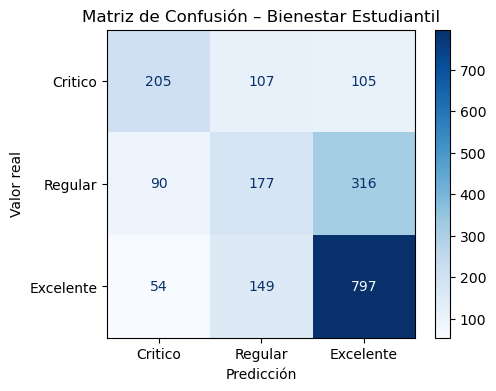

In [68]:
# ===============================
# 📊 Matriz de Confusión – Bienestar Estudiantil
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Generar predicciones
y_pred_bien = np.argmax(modelo_bien.predict(X_test_bien_proc), axis=1)

# Calcular la matriz
matriz_bien = confusion_matrix(y_test_bien, y_pred_bien)

# Mostrar en pantalla
print("Matriz de confusión:\n", matriz_bien)

# Visualizar con etiquetas legibles
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz_bien, display_labels=orden_bienestar).plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión – Bienestar Estudiantil")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [60]:
# Ejemplo: Escenario crítico (malas condiciones)
nuevo_estudiante_bien = pd.DataFrame({
    'estres': ['Muy Alto'],                # mucho estrés
    'apoyo_social': ['Insuficiente'],      # poco apoyo
    'horas_extracurriculares': ['Bajas']   # pocas actividades extracurriculares
})

# Transformar el nuevo caso con el preprocesador
X_new_bien_proc = preprocessor_bien.transform(nuevo_estudiante_bien)

# Obtener probabilidades
proba_bien = modelo_bien.predict(X_new_bien_proc, verbose=0)[0]

# Determinar clase predicha
pred_label_bien = orden_bienestar[np.argmax(proba_bien)]

print("Predicción:", pred_label_bien)
print("Probabilidades:", dict(zip(orden_bienestar, np.round(proba_bien, 3))))


Predicción: Critico
Probabilidades: {'Critico': 0.515, 'Regular': 0.306, 'Excelente': 0.179}


### ✅ Modelo General

In [61]:
def predecir_estudiante(data):
    """
    Predice rendimiento, riesgo de deserción y bienestar estudiantil
    a partir de los tres modelos entrenados.
    """
    resultados = {}

    # --- Rendimiento académico ---
    X_rend = data[['pps_actual_20', 'horas_de_estudio_semana', 'indice_procrastinacion']]
    X_rend_proc = preprocessor_rend.transform(X_rend)
    proba_rend = modelo_rend.predict(X_rend_proc, verbose=0)[0]
    pred_rend = orden_rendimiento[np.argmax(proba_rend)]
    resultados['Rendimiento'] = {
        'Predicción': pred_rend,
        'Probabilidades': dict(zip(orden_rendimiento, np.round(proba_rend, 3)))
    }

    # --- Riesgo de Deserción ---
    X_des = data[['horas_trabajo_semana', 'estres', 'apoyo_social']]
    X_des_proc = preprocessor_des.transform(X_des)
    proba_des = modelo_des.predict(X_des_proc, verbose=0)[0]
    pred_des = orden_desercion[np.argmax(proba_des)]
    resultados['Deserción'] = {
        'Predicción': pred_des,
        'Probabilidades': dict(zip(orden_desercion, np.round(proba_des, 3)))
    }

    # --- Bienestar Estudiantil ---
    X_bien = data[['estres', 'apoyo_social']]
    X_bien_proc = preprocessor_bien.transform(X_bien)
    proba_bien = modelo_bien.predict(X_bien_proc, verbose=0)[0]
    pred_bien = orden_bienestar[np.argmax(proba_bien)]
    resultados['Bienestar'] = {
        'Predicción': pred_bien,
        'Probabilidades': dict(zip(orden_bienestar, np.round(proba_bien, 3)))
    }

    return resultados


**Caso 1**

In [62]:
# Datos completos del estudiante
nuevo_estudiante_total = pd.DataFrame({
    'pps_actual_20': [clasificar_nota_pps(1)],
    'horas_de_estudio_semana': ['Insuficiente'],
    'indice_procrastinacion': ['Constante'],
    'horas_trabajo_semana': ['Tiempo Completo'],
    'estres': ['Muy Alto'],
    'apoyo_social': ['Insuficiente']
})

# Predicción global
resultado_final = predecir_estudiante(nuevo_estudiante_total)


# Mostrar resultados de cada modelo
print("\n===== 🧩 CASO 1: ESTUDIANTE EN RIESGO =====")
for variable, resultado in resultado_final.items():
    print(f"\n🧠 {variable}")
    print(f"Predicción: {resultado['Predicción']}")
    print(f"Probabilidades: {resultado['Probabilidades']}")

print("Umbral de nota: "  ,clasificar_nota_pps(1))


===== 🧩 CASO 1: ESTUDIANTE EN RIESGO =====

🧠 Rendimiento
Predicción: Inicio
Probabilidades: {'Destacado': 0.001, 'Previsto': 0.021, 'En_Proceso': 0.048, 'Inicio': 0.93}

🧠 Deserción
Predicción: Medio
Probabilidades: {'Bajo': 0.266, 'Medio': 0.38, 'Alto': 0.355}

🧠 Bienestar
Predicción: Critico
Probabilidades: {'Critico': 0.515, 'Regular': 0.306, 'Excelente': 0.179}
Umbral de nota:  Inicio


**Caso 2**

In [64]:
# Caso 2: estudiante mas o menos
estudiante_equilibrado = pd.DataFrame({
    'pps_actual_20': [clasificar_nota_pps(14)],
    'horas_de_estudio_semana': ['Adecuado'],
    'indice_procrastinacion': ['Frecuente'],
    'horas_trabajo_semana': ['Parcial Baja'],
    'estres': ['Moderado'],
    'apoyo_social': ['Bueno']
})

resultado_equilibrado = predecir_estudiante(estudiante_equilibrado)

print("\n===== 🧩 CASO 2: ESTUDIANTE MODERADO =====")
for variable, resultado in resultado_equilibrado.items():
    print(f"\n🧠 {variable}")
    print(f"Predicción: {resultado['Predicción']}")
    print(f"Probabilidades: {resultado['Probabilidades']}")

print("Umbral de nota:", clasificar_nota_pps(3))



===== 🧩 CASO 2: ESTUDIANTE MODERADO =====

🧠 Rendimiento
Predicción: Previsto
Probabilidades: {'Destacado': 0.288, 'Previsto': 0.302, 'En_Proceso': 0.282, 'Inicio': 0.128}

🧠 Deserción
Predicción: Bajo
Probabilidades: {'Bajo': 0.761, 'Medio': 0.185, 'Alto': 0.054}

🧠 Bienestar
Predicción: Excelente
Probabilidades: {'Critico': 0.081, 'Regular': 0.258, 'Excelente': 0.661}
Umbral de nota: Inicio


**Caso 3**

In [66]:
# Caso 3: estudiante excelente
estudiante_equilibrado = pd.DataFrame({
    'pps_actual_20': [clasificar_nota_pps(18)],
    'horas_de_estudio_semana': ['Adecuado'],
    'indice_procrastinacion': ['Minimo'],
    'horas_trabajo_semana': ['Parcial Baja'],
    'estres': ['Moderado'],
    'apoyo_social': ['Excelente']
})

resultado_equilibrado = predecir_estudiante(estudiante_equilibrado)

print("\n===== 🧩 CASO 3: ESTUDIANTE DESTACADO =====")
for variable, resultado in resultado_equilibrado.items():
    print(f"\n🧠 {variable}")
    print(f"Predicción: {resultado['Predicción']}")
    print(f"Probabilidades: {resultado['Probabilidades']}")

print("Umbral de nota:", clasificar_nota_pps(3))



===== 🧩 CASO 3: ESTUDIANTE DESTACADO =====

🧠 Rendimiento
Predicción: Destacado
Probabilidades: {'Destacado': 0.934, 'Previsto': 0.042, 'En_Proceso': 0.022, 'Inicio': 0.002}

🧠 Deserción
Predicción: Bajo
Probabilidades: {'Bajo': 0.79, 'Medio': 0.155, 'Alto': 0.055}

🧠 Bienestar
Predicción: Excelente
Probabilidades: {'Critico': 0.042, 'Regular': 0.19, 'Excelente': 0.768}
Umbral de nota: Inicio
